<a href="https://colab.research.google.com/github/ne10s/CYSE635-MNIST-CNN/blob/main/Copy_of_CYSE635_MNIST_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import **Pytorch** libraries and APIs.


In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets
from torch.utils.data import Subset
from torch.autograd import Variable
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# define the function of displaying multiple images
def show_images(images) -> None:
    n: int = images.size(0)

    f = plt.figure(figsize=(24, 6))
    for i in range(n):
        # Debug, plot figure
        f.add_subplot(1, n, i + 1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.axis('off')

    plt.show(block=True)

# define the function of displaying multiple images
def show_images_withPred(images,label,pred,conf) -> None:
    n: int = images.size(0)

    f = plt.figure(figsize=(24, 6))
    for i in range(n):
        # Debug, plot figure
        f.add_subplot(1, n, i + 1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title("{} -> {}".format(label[i], pred[i]))
        #plt.title("Conf:{} \n {} -> {}".format(conf[i][pred[i]]*100,label[i], pred[i]))
        plt.axis('off')

    plt.show(block=True)


After loaded the ML framework, we can then start to build the deep neural network (DNN) for image recognition. The training of a DNN has several key components:


1.   **Data**: Training and testing data set
2.   **Model**: A well-designed DNN that will be used for training and testing.
1.   **Criterion**: A metric function to measure the distance between the current prediction with the groundtruth (label).
2.   **Optimizer**: A algorithm to update the parameters of the DNN based on the result of criterion function.



# **Data**
MNIST: Images of hand written digits.

How many?

What size?

How do they look like?

What are training and testing dataset?

In [28]:
# Hyperparameters and Data loaders
num_epochs = 10
num_classes = 10
batch_size = 256
learning_rate = 0.001


DATA_PATH = 'data/'
MODEL_STORE_PATH = 'models/'

# transforms to apply to the data
trans = transforms.Compose([transforms.ToTensor()])

# MNIST dataset
train_dataset = torchvision.datasets.MNIST(root=DATA_PATH, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.MNIST(root=DATA_PATH, train=False, transform=trans)

#New code split 9/30/2026 Neten
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(
    train_dataset,
    [50000, 10000],
    generator=torch.Generator().manual_seed(42)
)
# Data loader redefined
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    num_workers=2,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=2,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=2,
    shuffle=False
)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))
# Data loader
##train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, num_workers=4, shuffle=True)
##test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, num_workers=4, shuffle=False)

Training samples: 50000
Validation samples: 10000
Testing samples: 10000
Training batches: 196
Validation batches: 40
Testing batches: 40


# **Deep Neural Network (Model)**

As human, we are able to identify those digits with highly abstracted knowledges.

Our eyes capture the lights from the image and turn into signals passing through the neurons in our brains, where different neurons represents diverse functionalities and knowledges.


**Question**: can we write a program to automatically recognize digits? If yes, what kind of program it is?

Traditional solutions (Machine Learning): hand-crafted features. For example, for digit one, we can define its feature to be 15 continous high pixel values in the middle of an image. However, it requires a lot of prior knowledge and often fails on complicated applications.

Deep Learning, or Deep Neural Network: Can we build a program similar to human brain?

Yes, we can have a mult-layer neural network, where each neuron outputs an activation value that represents the existance of an abstracted feature.

(1) Input layer: 28*28 neurons -- size of input image: 28x28 pixel values

(2) Hidden layer: 128 neurons

(3) Hidden layer: 64 neurons

(4) Output layer: 10 neurons -- number of classes 0-9



In [29]:
# neural network
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),

            nn.Linear(128, 64),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        out = self.classifier(x)

        return out


model=ConvNet()
model.cuda()
model.train()

ConvNet(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [30]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)



In [31]:
model.train()
loss_list = []
acc_list = []
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.cuda()
    labels = labels.cuda()

    outputs = model(images)

    loss = criterion(outputs, labels)
    loss_list.append(loss.item())

    # Backprop and percform Adam optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track the accuracy
    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    acc_list.append(correct / total)

    if (i%150 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))



Epoch [1/10], Step [0/196], Loss: 2.3059, Accuracy: 18.36%
Epoch [1/10], Step [150/196], Loss: 0.3460, Accuracy: 91.02%
Epoch [2/10], Step [0/196], Loss: 0.2818, Accuracy: 91.41%
Epoch [2/10], Step [150/196], Loss: 0.1958, Accuracy: 92.58%
Epoch [3/10], Step [0/196], Loss: 0.3354, Accuracy: 89.45%
Epoch [3/10], Step [150/196], Loss: 0.3857, Accuracy: 88.28%
Epoch [4/10], Step [0/196], Loss: 0.2911, Accuracy: 90.62%
Epoch [4/10], Step [150/196], Loss: 0.3115, Accuracy: 87.89%
Epoch [5/10], Step [0/196], Loss: 0.2692, Accuracy: 92.19%
Epoch [5/10], Step [150/196], Loss: 0.1812, Accuracy: 94.92%
Epoch [6/10], Step [0/196], Loss: 0.1825, Accuracy: 96.48%
Epoch [6/10], Step [150/196], Loss: 0.2551, Accuracy: 92.19%
Epoch [7/10], Step [0/196], Loss: 0.2133, Accuracy: 94.14%
Epoch [7/10], Step [150/196], Loss: 0.2099, Accuracy: 94.14%
Epoch [8/10], Step [0/196], Loss: 0.1634, Accuracy: 95.31%
Epoch [8/10], Step [150/196], Loss: 0.3053, Accuracy: 92.97%
Epoch [9/10], Step [0/196], Loss: 0.1793

In [49]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for images, labels in test_loader:
      images = images.cuda()
      labels = labels.cuda()

      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Accuracy of the model on the 10000 test images: {} %'.format((correct / total) * 100))

Accuracy of the model on the 10000 test images: 95.94 %


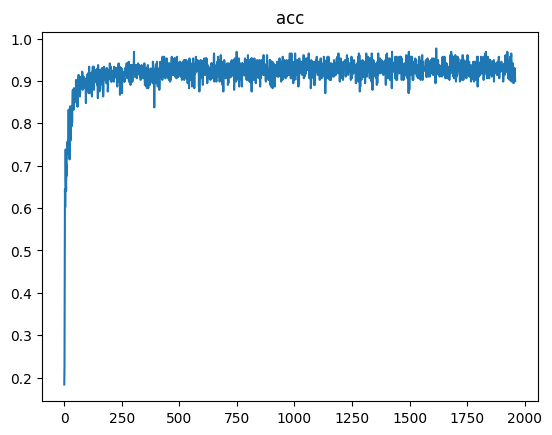

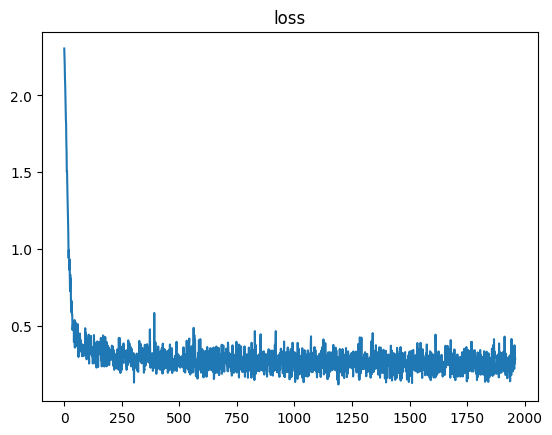

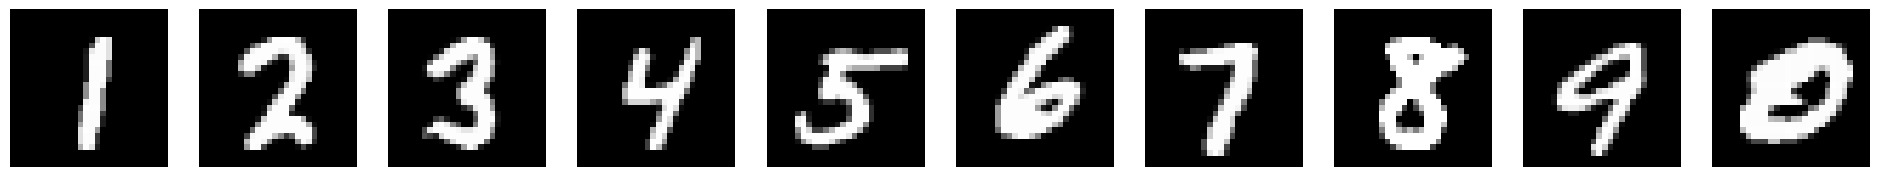

In [45]:
plt.figure()
plt.plot(acc_list)
plt.title('acc')

plt.figure()
plt.plot(loss_list)
plt.title('loss')

show_images(images[:10])

# **Can we improve the performance of the trained DNN model?**

First, let us take a look at those mis-classified images to gain deeper understanding.

Incorrect Predictions:


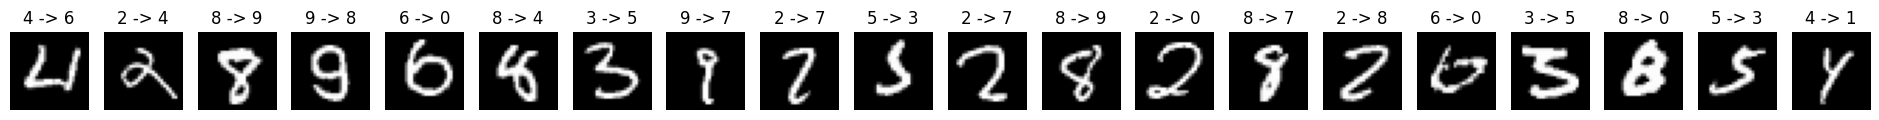

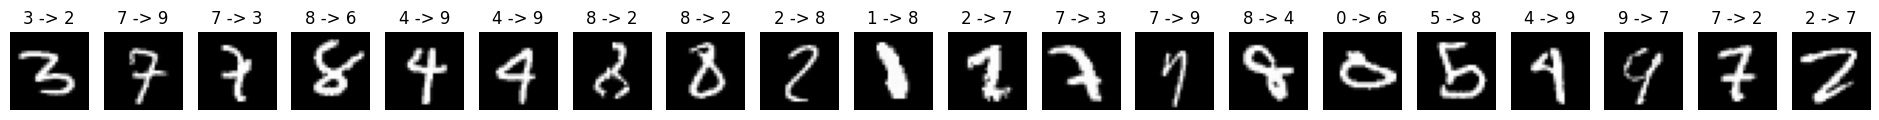

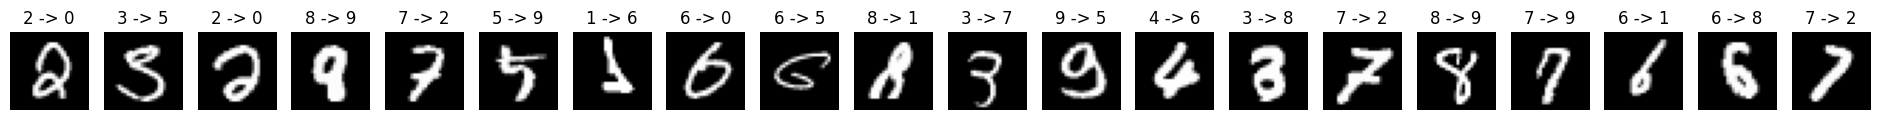

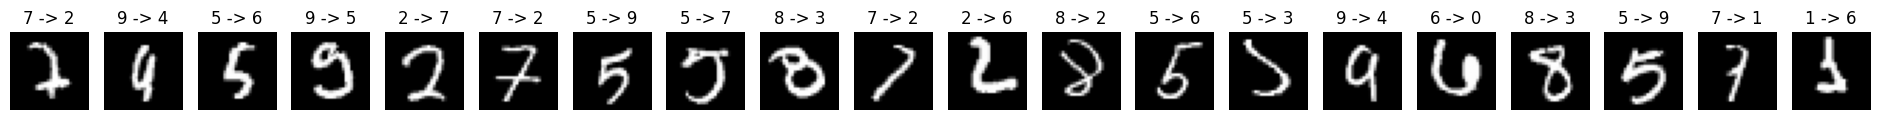


 
 Correct Predictions:


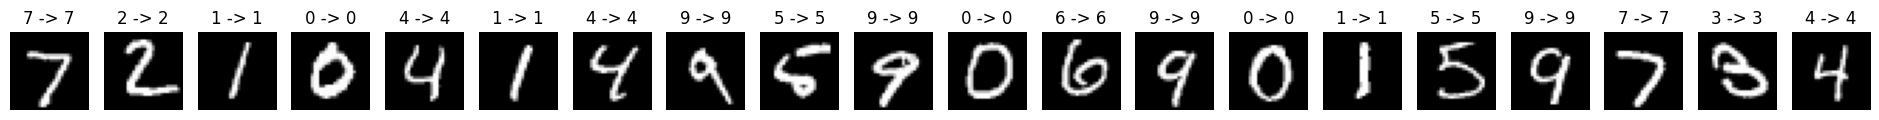

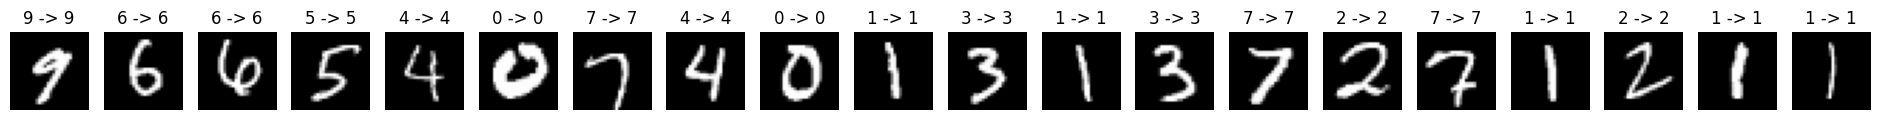

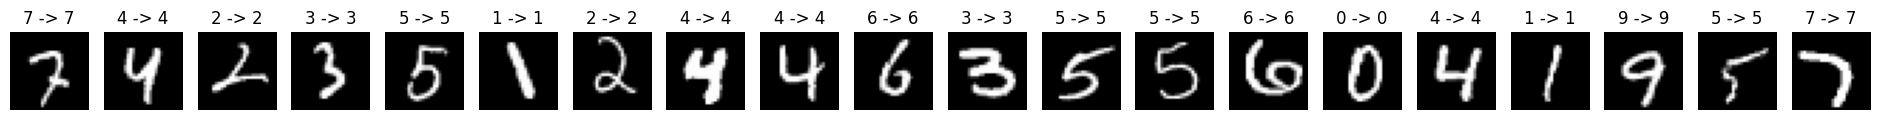

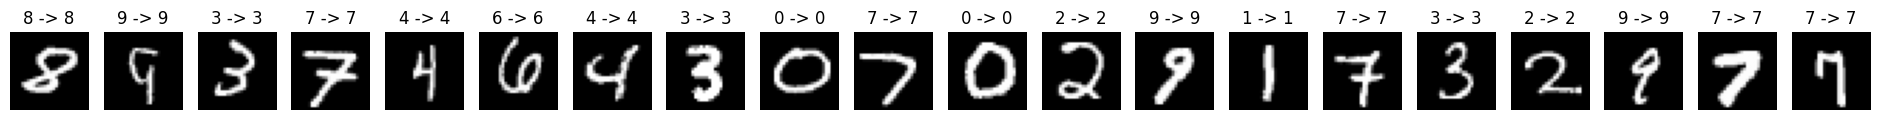

In [46]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for i, (images, labels) in enumerate(test_loader):
      images = images.cuda()
      labels = labels.cuda()

      outputs = model(images)
      confidences = outputs.softmax(1)
      _, predicted = torch.max(outputs.data, 1)
      correct_idx = predicted == labels
      incorrect_idx = predicted != labels

      if i == 0:
        correct_images, correct_labels, correct_pred, correct_conf = images[correct_idx], labels[correct_idx], predicted[correct_idx], confidences[correct_idx]
        incorrect_images, incorrect_labels, incorrect_pred, incorrect_conf = images[incorrect_idx], labels[incorrect_idx], predicted[incorrect_idx], confidences[incorrect_idx]
      else:
        correct_images, correct_labels, correct_pred, correct_conf = torch.cat((correct_images, images[correct_idx]),0), torch.cat((correct_labels, labels[correct_idx]),0), torch.cat((correct_pred, predicted[correct_idx]),0), torch.cat((correct_conf, confidences[correct_idx]),0)
        incorrect_images, incorrect_labels, incorrect_pred, incorrect_conf = torch.cat((incorrect_images, images[incorrect_idx]),0), torch.cat((incorrect_labels, labels[incorrect_idx]),0), torch.cat((incorrect_pred, predicted[incorrect_idx]),0), torch.cat((incorrect_conf, confidences[incorrect_idx]),0)

print("Incorrect Predictions:")
plt_num = 20
for i in range(4):
  show_images_withPred(incorrect_images[i*plt_num:(i+1)*plt_num], incorrect_labels[i*plt_num:(i+1)*plt_num],incorrect_pred[i*plt_num:(i+1)*plt_num], correct_conf[i*plt_num:(i+1)*plt_num])

print("\n \n Correct Predictions:")
for i in range(4):
  show_images_withPred(correct_images[i*plt_num:(i+1)*plt_num], correct_labels[i*plt_num:(i+1)*plt_num],correct_pred[i*plt_num:(i+1)*plt_num], incorrect_conf[i*plt_num:(i+1)*plt_num])

del correct_images, correct_labels,correct_pred,correct_conf,incorrect_images,incorrect_labels,incorrect_pred,incorrect_conf

What can we learn from the above observation?

The model is not good enough for extracting useful features. We need to improve it. But how?

In [47]:
# CNN
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(1, -1),
        )
        self.fc1 = nn.Linear(7 * 7 * 16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        out = self.features(x)
        out = self.fc1(out)
        out = self.fc2(out)
        out = self.fc3(out)

        return out


model=LeNet()
model.cuda()
model.train()

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.03)

In [10]:
##Avoid this cell, got replaced by following cell
model.train()
loss_list_cnn = []
acc_list_cnn = []
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.cuda()
    labels = labels.cuda()

    outputs = model(images)

    loss = criterion(outputs, labels)
    loss_list_cnn.append(loss.item())

    # Backprop and percform Adam optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track the accuracy
    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    acc_list_cnn.append(correct / total)

    if (i%150 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))


model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for images, labels in test_loader:
      images = images.cuda()
      labels = labels.cuda()

      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Accuracy of the model on the 10000 test images: {} %'.format((correct / total) * 100))

Epoch [1/10], Step [0/196], Loss: 2.2965, Accuracy: 7.03%
Epoch [1/10], Step [150/196], Loss: 0.3417, Accuracy: 93.36%
Epoch [2/10], Step [0/196], Loss: 0.2923, Accuracy: 91.41%
Epoch [2/10], Step [150/196], Loss: 0.2275, Accuracy: 94.14%
Epoch [3/10], Step [0/196], Loss: 0.2001, Accuracy: 96.09%
Epoch [3/10], Step [150/196], Loss: 0.1757, Accuracy: 95.31%
Epoch [4/10], Step [0/196], Loss: 0.1767, Accuracy: 94.53%
Epoch [4/10], Step [150/196], Loss: 0.1935, Accuracy: 96.09%
Epoch [5/10], Step [0/196], Loss: 0.2081, Accuracy: 93.36%
Epoch [5/10], Step [150/196], Loss: 0.2056, Accuracy: 94.92%
Epoch [6/10], Step [0/196], Loss: 0.2253, Accuracy: 93.36%
Epoch [6/10], Step [150/196], Loss: 0.1926, Accuracy: 94.14%
Epoch [7/10], Step [0/196], Loss: 0.1574, Accuracy: 96.48%
Epoch [7/10], Step [150/196], Loss: 0.2651, Accuracy: 92.97%
Epoch [8/10], Step [0/196], Loss: 0.2538, Accuracy: 93.75%
Epoch [8/10], Step [150/196], Loss: 0.1370, Accuracy: 95.31%
Epoch [9/10], Step [0/196], Loss: 0.2065,

In [48]:
##Ver.2 Run this for model.train!
import copy
import time

model.train()

loss_list_cnn = []
acc_list_cnn = []

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')
best_model_weights = copy.deepcopy(model.state_dict())
best_epoch = 0

patience = 3
epochs_without_improvement = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

start_time = time.time()

for epoch in range(num_epochs):

    # Training phase
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in train_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)

        batch_total = labels.size(0)
        batch_correct = (predicted == labels).sum().item()

        loss_list_cnn.append(loss.item())
        acc_list_cnn.append(batch_correct / batch_total)

        running_loss += loss.item() * batch_total
        running_correct += batch_correct
        running_total += batch_total

    epoch_train_loss = running_loss / running_total
    epoch_train_acc = running_correct / running_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # Validation phase
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.cuda()
            labels = labels.cuda()

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)

            val_running_loss += loss.item() * labels.size(0)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Accuracy: {epoch_train_acc*100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Accuracy: {epoch_val_acc*100:.2f}%"
    )

    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

model.load_state_dict(best_model_weights)
model.eval()

training_time = time.time() - start_time

print("\nTraining complete")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Training time: {training_time:.2f} seconds")

Epoch [1/10] | Train Loss: 0.6303 | Train Accuracy: 81.73% | Val Loss: 0.3005 | Val Accuracy: 91.01%
Epoch [2/10] | Train Loss: 0.2522 | Train Accuracy: 93.06% | Val Loss: 0.2334 | Val Accuracy: 93.61%
Epoch [3/10] | Train Loss: 0.2208 | Train Accuracy: 94.02% | Val Loss: 0.2039 | Val Accuracy: 94.79%
Epoch [4/10] | Train Loss: 0.2012 | Train Accuracy: 94.70% | Val Loss: 0.2056 | Val Accuracy: 94.31%
Epoch [5/10] | Train Loss: 0.1953 | Train Accuracy: 94.82% | Val Loss: 0.2178 | Val Accuracy: 94.13%
Epoch [6/10] | Train Loss: 0.1896 | Train Accuracy: 94.98% | Val Loss: 0.1932 | Val Accuracy: 95.07%
Epoch [7/10] | Train Loss: 0.1851 | Train Accuracy: 95.24% | Val Loss: 0.2194 | Val Accuracy: 93.66%
Epoch [8/10] | Train Loss: 0.1854 | Train Accuracy: 95.14% | Val Loss: 0.1990 | Val Accuracy: 94.77%
Epoch [9/10] | Train Loss: 0.1838 | Train Accuracy: 95.21% | Val Loss: 0.1877 | Val Accuracy: 95.42%
Epoch [10/10] | Train Loss: 0.1812 | Train Accuracy: 95.30% | Val Loss: 0.1790 | Val Accura

              precision    recall  f1-score   support

           0     0.9669    0.9847    0.9757       980
           1     0.9825    0.9894    0.9860      1135
           2     0.9491    0.9574    0.9532      1032
           3     0.9422    0.9683    0.9551      1010
           4     0.9585    0.9644    0.9614       982
           5     0.9685    0.9641    0.9663       892
           6     0.9578    0.9708    0.9642       958
           7     0.9678    0.9358    0.9515      1028
           8     0.9502    0.9209    0.9353       974
           9     0.9487    0.9356    0.9421      1009

    accuracy                         0.9594     10000
   macro avg     0.9592    0.9591    0.9591     10000
weighted avg     0.9594    0.9594    0.9593     10000



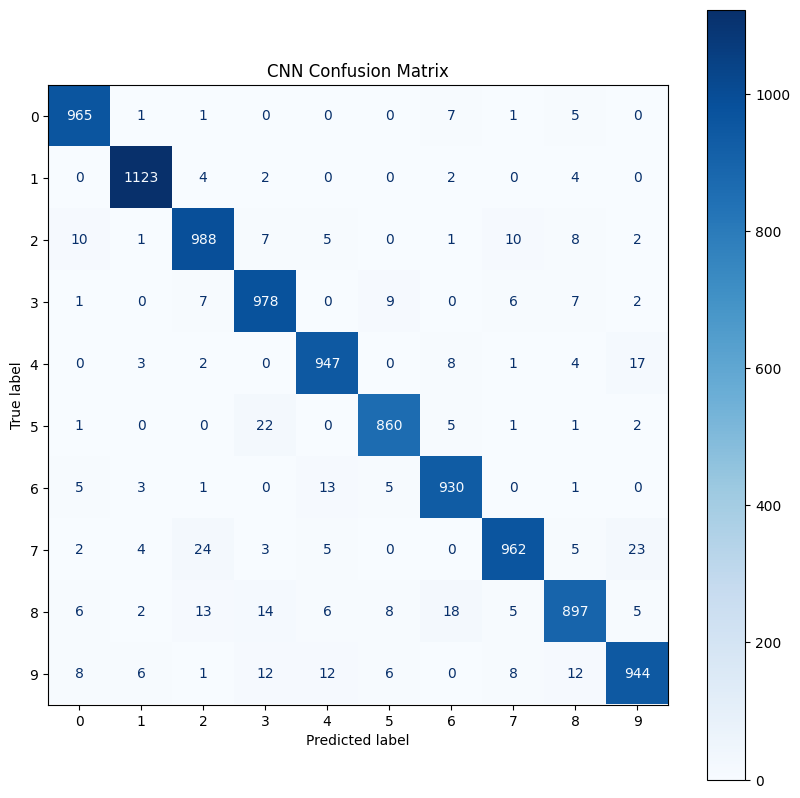

In [58]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

print(classification_report(
    all_labels,
    all_predictions,
    digits=4
))

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(10))
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("CNN Confusion Matrix")
plt.show()

In [38]:
# Find the most common misclassification pairs
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

confusion_pairs = []

for actual_digit in range(10):
    for predicted_digit in range(10):
        if actual_digit != predicted_digit and cm_copy[actual_digit, predicted_digit] > 0:
            confusion_pairs.append(
                (cm_copy[actual_digit, predicted_digit],
                 actual_digit,
                 predicted_digit)
            )

confusion_pairs.sort(reverse=True)

print("Top 10 confusion pairs:")
for count, actual_digit, predicted_digit in confusion_pairs[:10]:
    print(
        f"Actual {actual_digit} predicted as {predicted_digit}: {count} times"
    )

Top 10 confusion pairs:
Actual 7 predicted as 2: 24 times
Actual 7 predicted as 9: 18 times
Actual 9 predicted as 4: 17 times
Actual 8 predicted as 9: 17 times
Actual 8 predicted as 5: 15 times
Actual 2 predicted as 0: 15 times
Actual 8 predicted as 3: 14 times
Actual 3 predicted as 5: 14 times
Actual 6 predicted as 0: 13 times
Actual 2 predicted as 7: 13 times


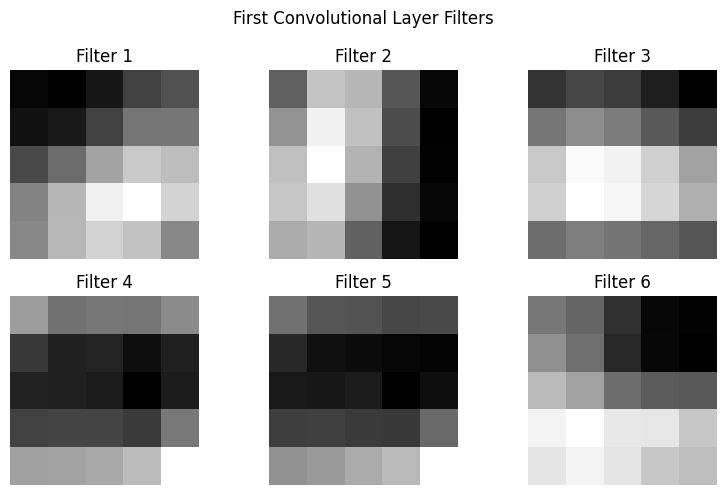

In [39]:
# Visualize filters from the first convolutional layer

filters = model.features[0].weight.data.cpu()

fig, axes = plt.subplots(2, 3, figsize=(8, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i][0], cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')

plt.suptitle('First Convolutional Layer Filters')
plt.tight_layout()
plt.show()

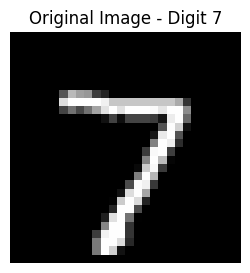

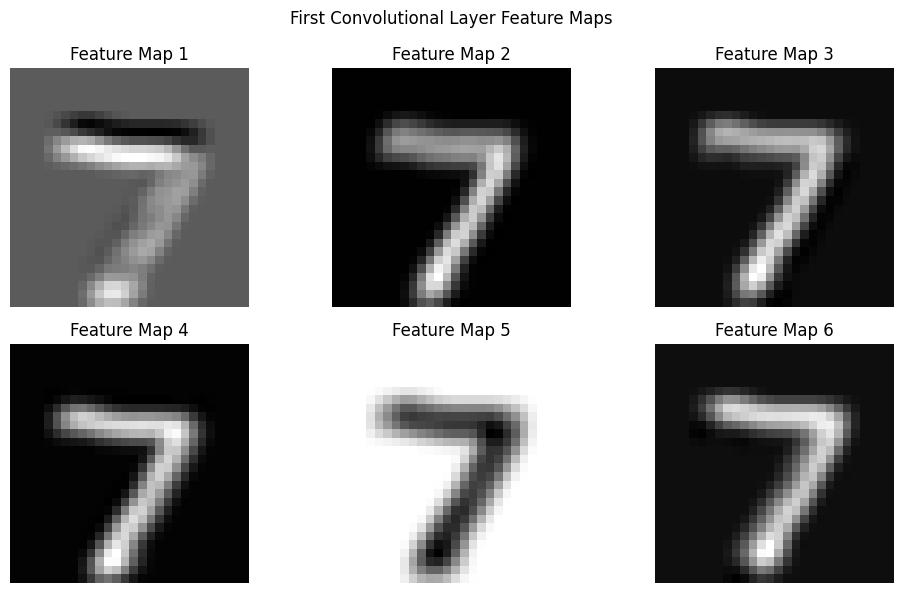

In [56]:
# Visualize feature maps from the first convolutional layer

model.eval()

# Get one test image
images, labels = next(iter(test_loader))
sample_image = images[0:1].cuda()
sample_label = labels[0].item()

# Pass image through first convolutional layer
with torch.no_grad():
    feature_maps = model.features[0](sample_image)

feature_maps = feature_maps.cpu()

# Display original image
plt.figure(figsize=(3, 3))
plt.imshow(sample_image.cpu().squeeze(), cmap='gray')
plt.title(f'Original Image - Digit {sample_label}')
plt.axis('off')
plt.show()

# Display the six feature maps
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, i], cmap='gray')
    ax.set_title(f'Feature Map {i+1}')
    ax.axis('off')

plt.suptitle('First Convolutional Layer Feature Maps')
plt.tight_layout()
plt.show()

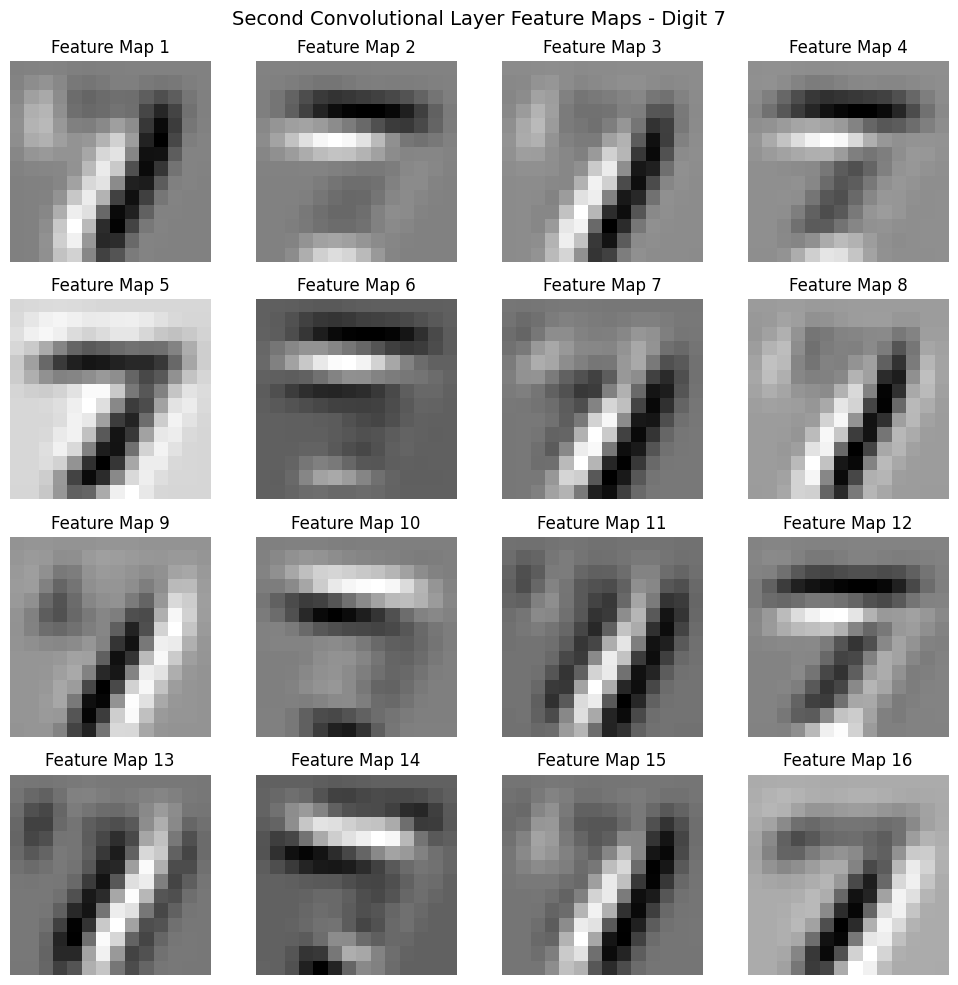

In [57]:
# Visualize feature maps from the second convolutional layer

model.eval()

images, labels = next(iter(test_loader))
sample_image = images[0:1].cuda()
sample_label = labels[0].item()

with torch.no_grad():
    # Conv1
    x = model.features[0](sample_image)

    # First MaxPool
    x = model.features[1](x)

    # Conv2
    feature_maps_conv2 = model.features[2](x)

feature_maps_conv2 = feature_maps_conv2.cpu()

# Display all 16 second-layer feature maps
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps_conv2[0, i], cmap='gray')
    ax.set_title(f'Feature Map {i+1}')
    ax.axis('off')

plt.suptitle(
    f'Second Convolutional Layer Feature Maps - Digit {sample_label}',
    fontsize=14
)
plt.tight_layout()
plt.show()

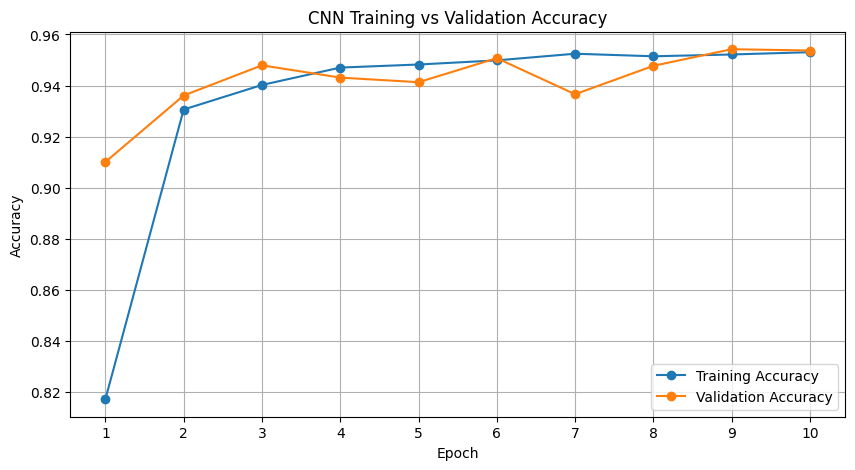

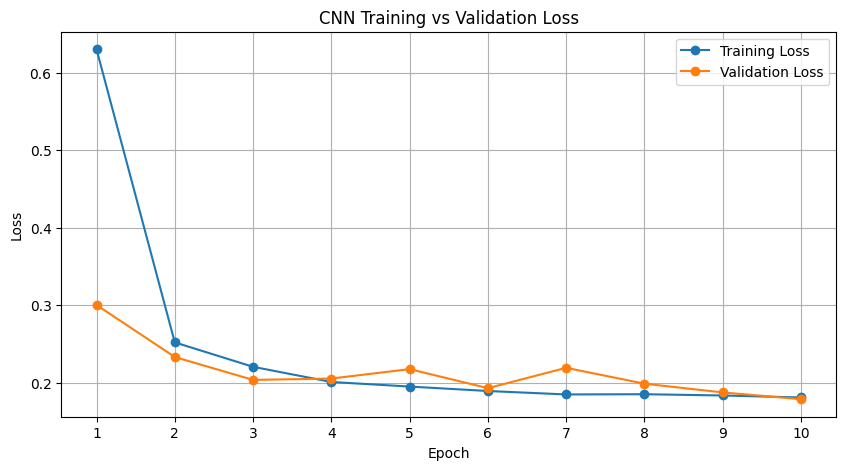

In [55]:

epochs = range(1, len(train_accuracies) + 1)
# Training vs Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training vs Validation Accuracy')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

# Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training vs Validation Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

Incorrect Predictions:


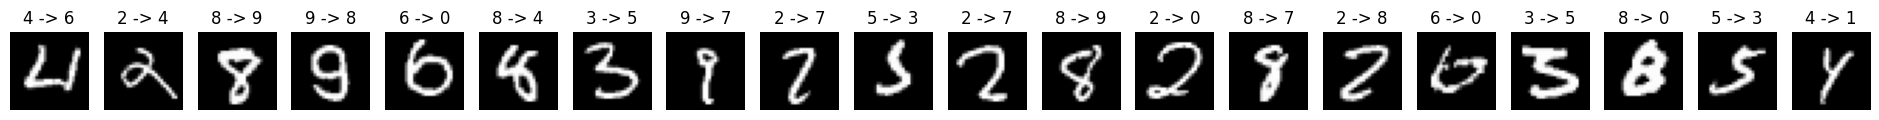

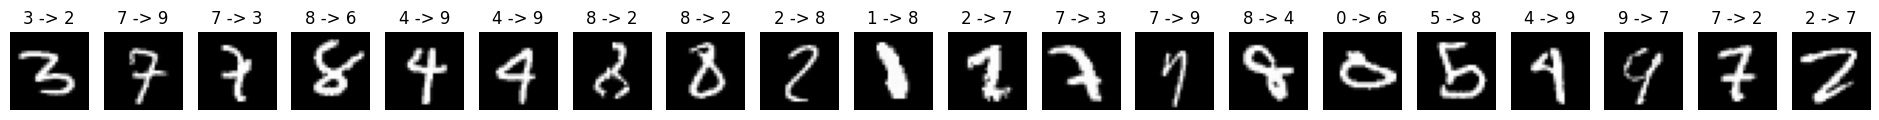

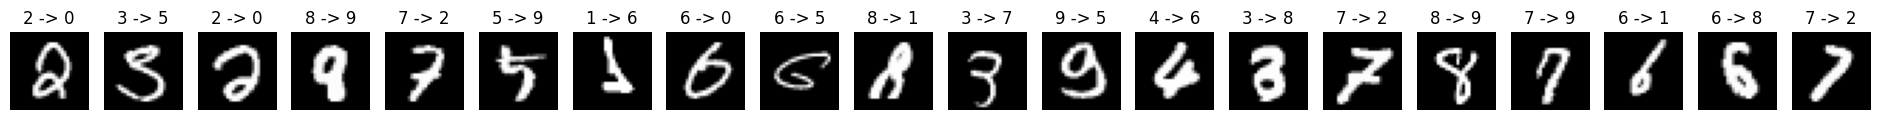

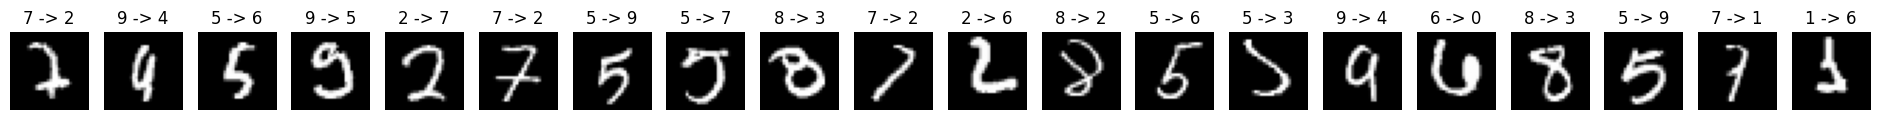



Correct Predictions:


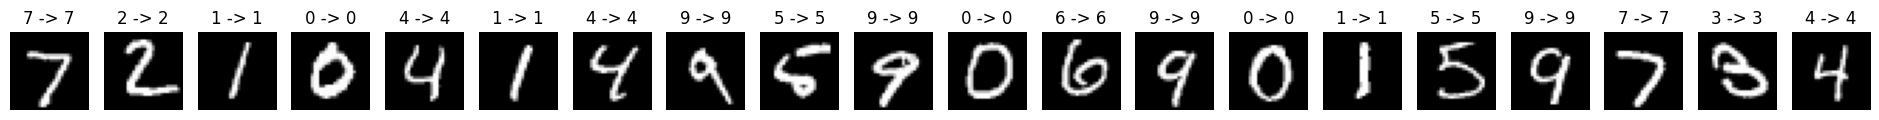

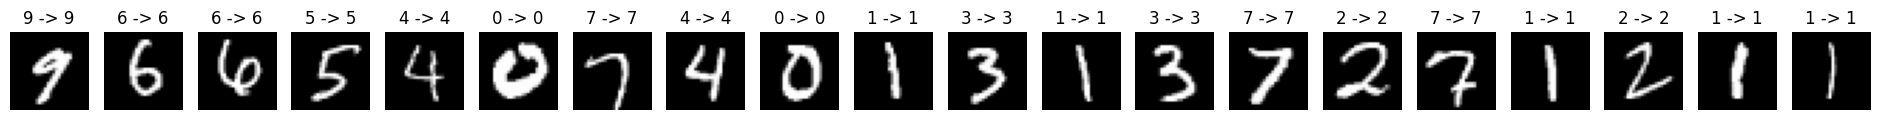

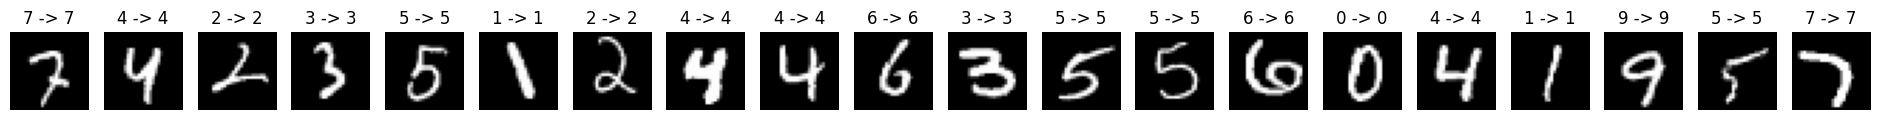

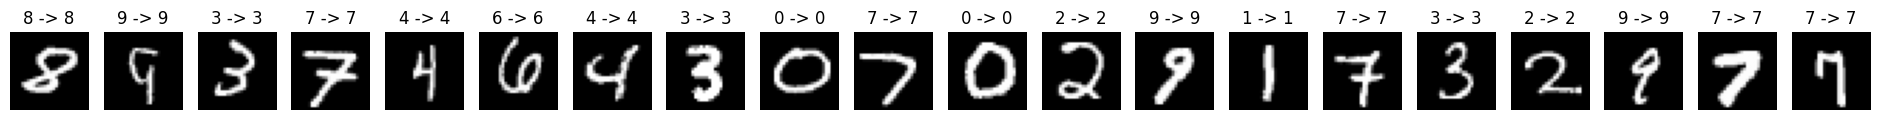

In [42]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for i, (images, labels) in enumerate(test_loader):
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)
        confidences = outputs.softmax(1)
        _, predicted = torch.max(outputs.data, 1)
        correct_idx = predicted == labels
        incorrect_idx = predicted != labels

        if i == 0:
            correct_images = images[correct_idx]
            correct_labels = labels[correct_idx]
            correct_pred = predicted[correct_idx]
            correct_conf = confidences[correct_idx]

            incorrect_images = images[incorrect_idx]
            incorrect_labels = labels[incorrect_idx]
            incorrect_pred = predicted[incorrect_idx]
            incorrect_conf = confidences[incorrect_idx]
        else:
            correct_images = torch.cat((correct_images, images[correct_idx]), 0)
            correct_labels = torch.cat((correct_labels, labels[correct_idx]), 0)
            correct_pred = torch.cat((correct_pred, predicted[correct_idx]), 0)
            correct_conf = torch.cat((correct_conf, confidences[correct_idx]), 0)

            incorrect_images = torch.cat((incorrect_images, images[incorrect_idx]), 0)
            incorrect_labels = torch.cat((incorrect_labels, labels[incorrect_idx]), 0)
            incorrect_pred = torch.cat((incorrect_pred, predicted[incorrect_idx]), 0)
            incorrect_conf = torch.cat((incorrect_conf, confidences[incorrect_idx]), 0)

print("Incorrect Predictions:")
plt_num = 20
for i in range(4):
    show_images_withPred(
        incorrect_images[i*plt_num:(i+1)*plt_num],
        incorrect_labels[i*plt_num:(i+1)*plt_num],
        incorrect_pred[i*plt_num:(i+1)*plt_num],
        incorrect_conf[i*plt_num:(i+1)*plt_num]
    )

print("\n\nCorrect Predictions:")
for i in range(4):
    show_images_withPred(
        correct_images[i*plt_num:(i+1)*plt_num],
        correct_labels[i*plt_num:(i+1)*plt_num],
        correct_pred[i*plt_num:(i+1)*plt_num],
        correct_conf[i*plt_num:(i+1)*plt_num]
    )

# Freeing memory by deleting large tensors after usage
del correct_images, correct_labels, correct_pred, correct_conf
del incorrect_images, incorrect_labels, incorrect_pred, incorrect_conf


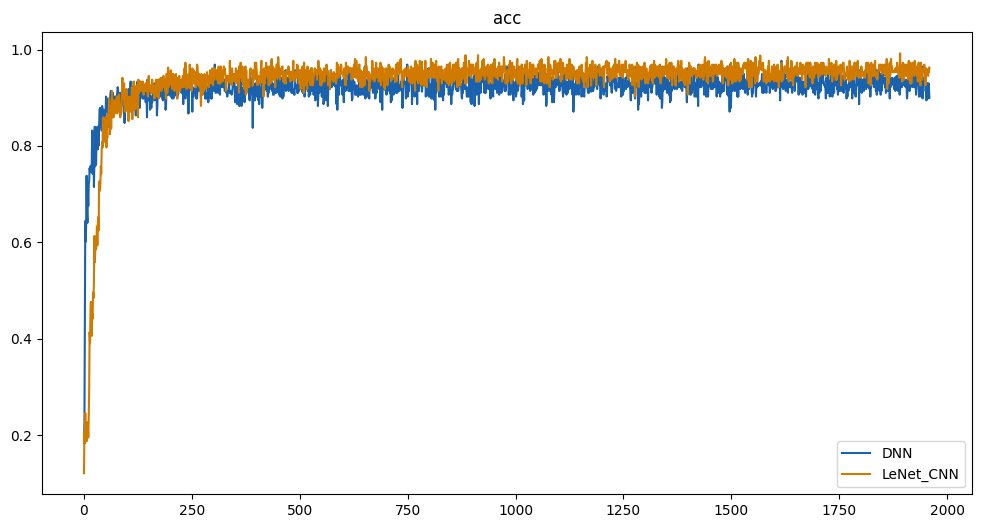

Text(0.5, 1.0, 'loss')

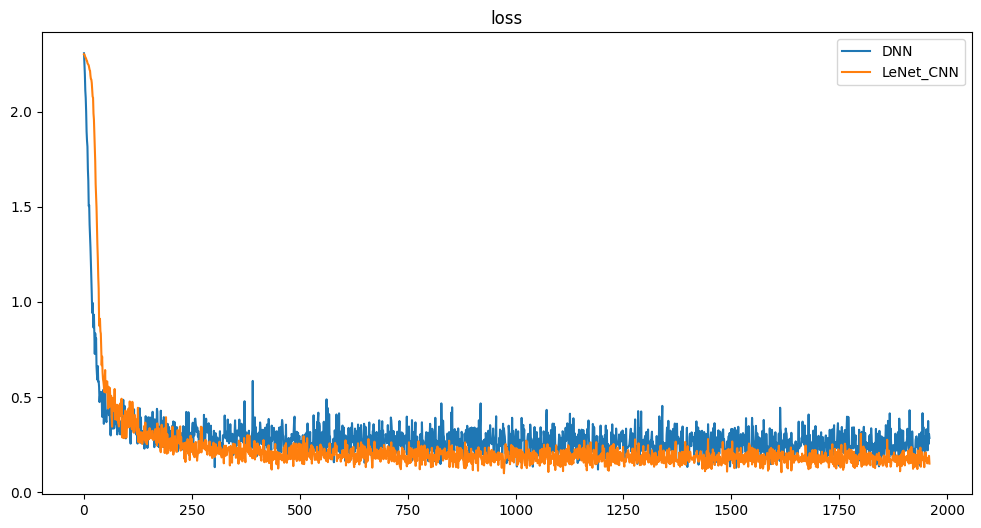

In [43]:
plt.figure(figsize=(12, 6))
plt.plot(acc_list, color='#1A62AE')  # DNN color: Blue
plt.plot(acc_list_cnn, color='#D17A00')  # LeNet_CNN color: Orange
plt.legend(['DNN', 'LeNet_CNN'])
plt.title('acc')
plt.show()


plt.figure(figsize=(12,6))
plt.plot(loss_list)
plt.plot(loss_list_cnn)
plt.legend(['DNN','LeNet_CNN'])
plt.title('loss')

# **Homework**
